In [55]:
import gc
import argparse
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import muspan as ms

In [56]:
input_path = Path("/Volumes/phenotypingsputumasthmaticsaurorawellcomea1/live/Sara_Patti/009_ST_Xenium/output/muspan")
out_path = Path("/Volumes/phenotypingsputumasthmaticsaurorawellcomea1/live/Sara_Patti/009_ST_Xenium/output/16S/muspan/")

In [57]:
# Load the domain inside the worker process
domain = ms.io.load_domain( str(input_path / "domains" / "IPF_RBH_16_muspan_domain.muspan") )
domain_name = "IPF_RBH_16"

MuSpAn domain loaded successfully. Domain summary:
Domain name: IPF_RBH_16
Number of objects: 202636
Collections: ['Cell boundaries', 'Nucleus boundaries', 'Transcripts', 'Cell centroids']
Labels: ['Cell ID', 'Transcript Counts', 'Cell Area', 'Nucleus Area', 'Transcript ID', 'Cell Type level 1', 'Cell Type', 'Cell Type level 3'] 
Networks: ['Delaunay CC', 'Delaunay CC filtered', 'Proximity_30um'] 
Distance matrices: []


In [58]:
level_1_palette = {
    "Airway epithelial cells":  "#7E9478",
    "Alveolar epithelial cells": "#7A6EA8",
    "Immune cells": "#B8964E",
    "Stromal cells": "#89B9C4",
    "Endothelial cells": "#A05A4A",
    "Unknown": "#828383",
}

domain.update_colors(
    level_1_palette, colors_to_update="labels", label_name="Cell Type level 1"
)

In [59]:
qTrans = ms.query.query(domain, ('Collection',), 'is', 'Transcripts')
boundCells = ms.query.query(domain, ("Collection",), "is", "Cell boundaries")
query_16S = ms.query.query(domain, ('label', 'Transcript ID'), 'is', '16S')

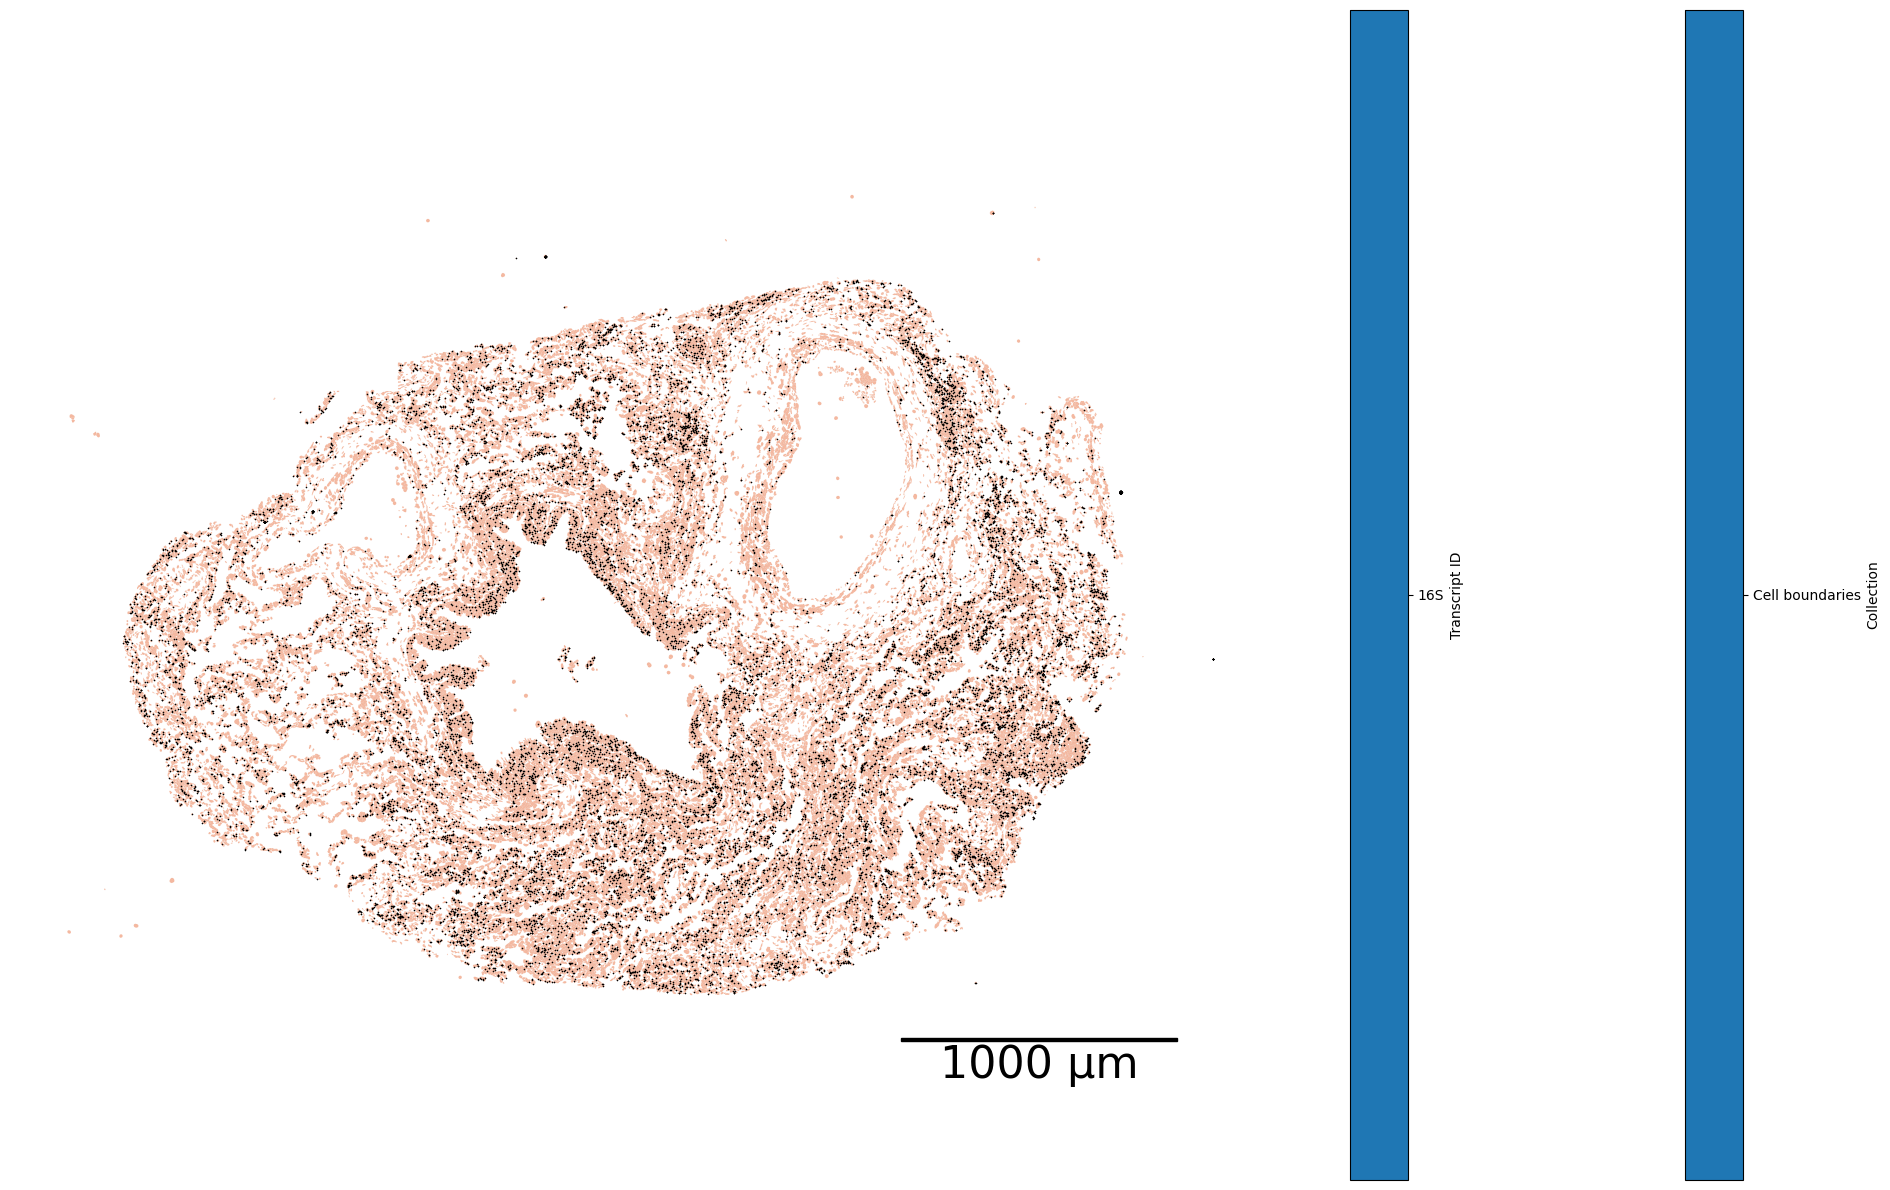

In [62]:
# Visualise transcripts, colored by 'Transcript'
fig, ax = plt.subplots(figsize=(20, 12))
ms.visualise.visualise(
        domain,
        objects_to_plot=boundCells,
        shape_kwargs={'alpha':0.5, 'linewidth': 0.005, 'edgecolor': "#00000000", 'color': "#EA7242"}, ax=ax
    )
ms.visualise.visualise(domain,
                       color_by=("label", "Transcript ID"), 
                       objects_to_plot=query_16S, 
                       marker_size=1, 
                       ax=ax, 
                       scatter_kwargs={'c': "#000000", 'edgecolor': "black", 'linewidth': 0.1},
                       add_scalebar=True, scalebar_kwargs={'size': 1000, 'label': '1000 µm', 'loc': 'lower right', 'pad': 2, 'color': 'black', 'frameon': False, 'size_vertical': 10}
                       )

plt.savefig(out_path / f"16S_{domain_name}_black_red.pdf", dpi=600)
plt.savefig(out_path / f"16S_{domain_name}_black_red.png", dpi=900)

KeyboardInterrupt: 

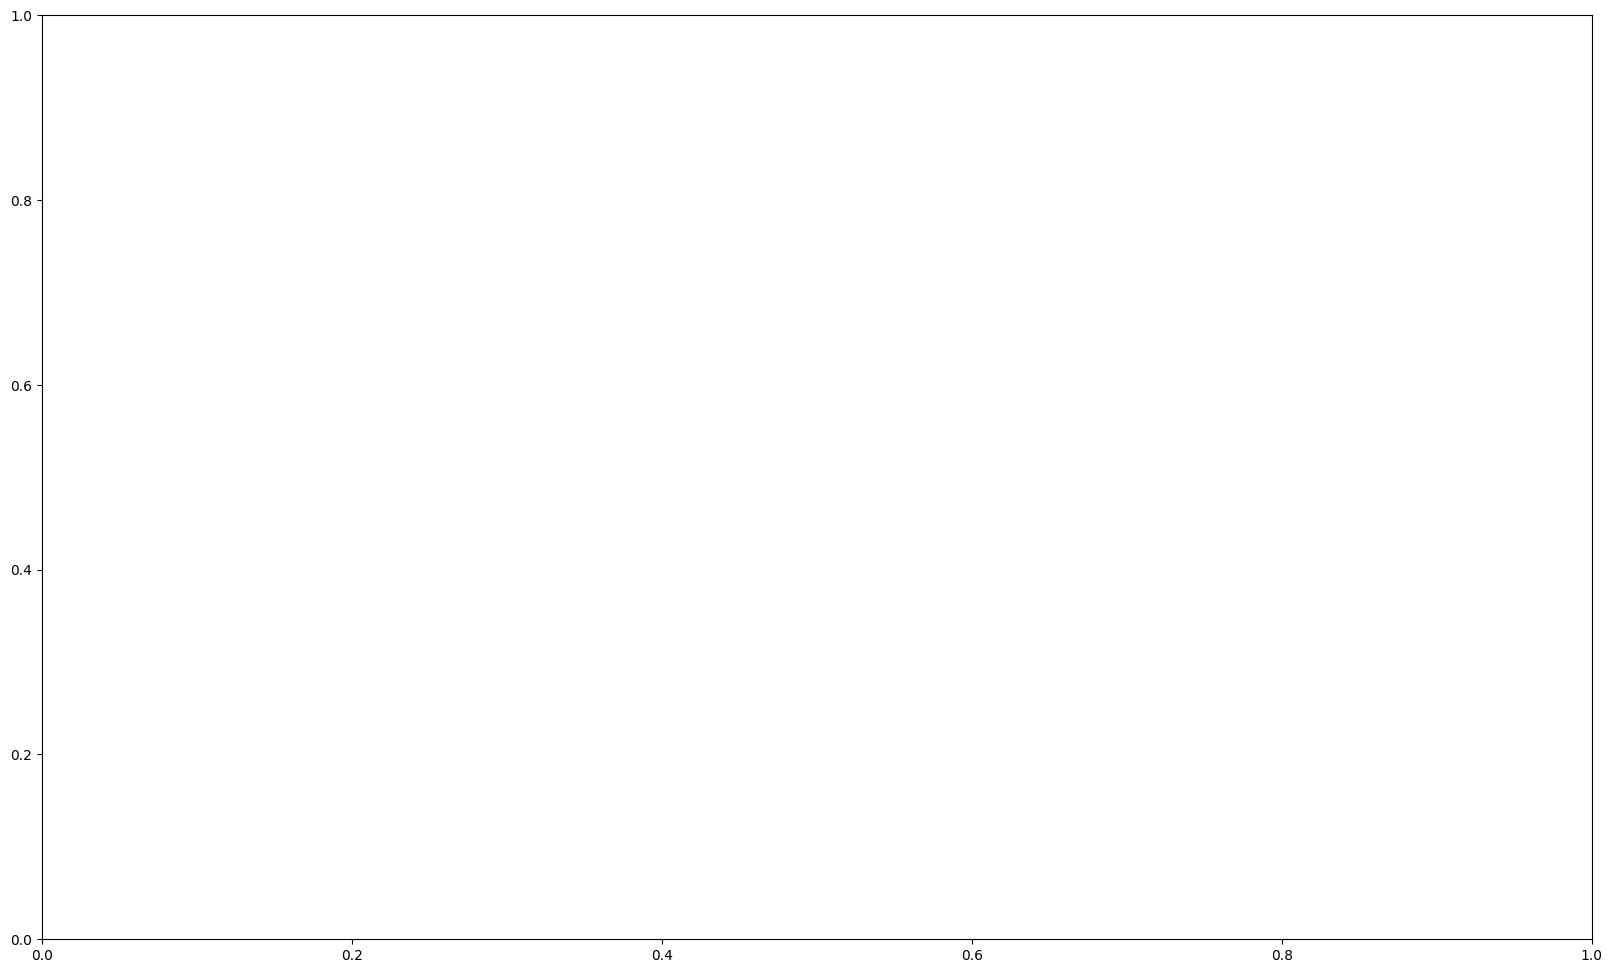

In [61]:
# Visualise transcripts, colored by 'Transcript'
fig, ax = plt.subplots(figsize=(20, 12))
ms.visualise.visualise(
        domain,
        color_by=("label", "Cell Type level 1"),
        objects_to_plot=boundCells,
        shape_kwargs=dict(alpha=1, linewidth=0.005, edgecolor="#00000000"), ax=ax,
    )
ms.visualise.visualise(domain,
                       color_by=("label", "Transcript ID"), 
                       objects_to_plot=query_16S,
                       marker_size=0.5, 
                       ax=ax, 
                       scatter_kwargs={'c': "#000000", 'edgecolor': None},
                       add_scalebar=True, scalebar_kwargs={'size': 1000, 'label': '1000 µm', 'loc': 'lower right', 'pad': 2, 'color': 'black', 'frameon': False, 'size_vertical': 10}
                       )

plt.savefig(out_path / f"16S_{domain_name}_level1_black.pdf", dpi=600)
plt.savefig(out_path / f"16S_{domain_name}_level1_black.png", dpi=900)

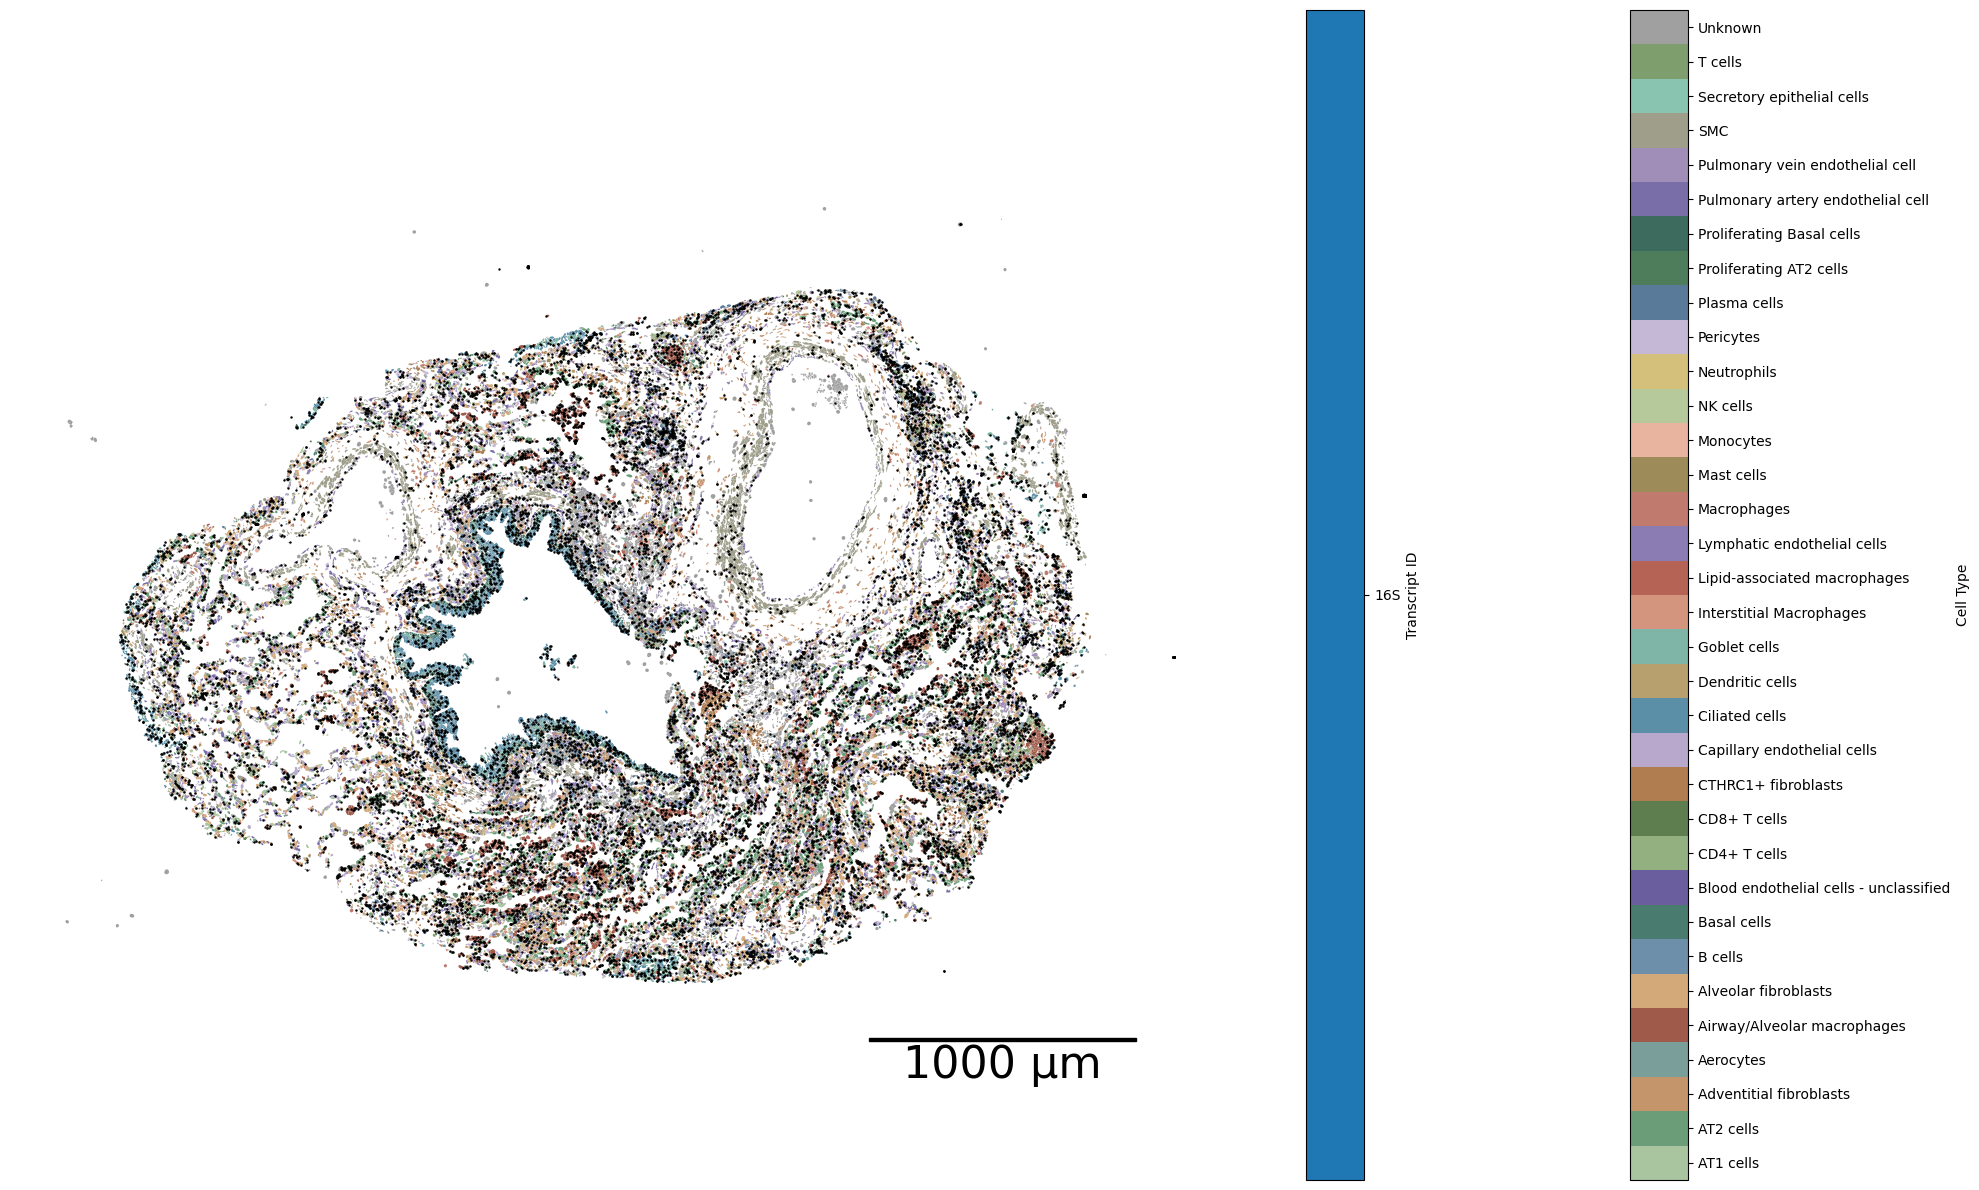

In [ ]:
# Visualise transcripts, colored by 'Transcript'
fig, ax = plt.subplots(figsize=(20, 12))
ms.visualise.visualise(
        domain,
        color_by=("label", "Cell Type"),
        objects_to_plot=boundCells,
        shape_kwargs=dict(alpha=1, linewidth=0.005, edgecolor="#00000000"), ax=ax
    )
ms.visualise.visualise(domain,
                       color_by=("label", "Transcript ID"), 
                       objects_to_plot=query_16S, 
                       marker_size=0.5, 
                       ax=ax, 
                       scatter_kwargs={'c': "#000000", 'edgecolor': None},
                       add_scalebar=True, scalebar_kwargs={'size': 1000, 'label': '1000 µm', 'loc': 'lower right', 'pad': 2, 'color': 'black', 'frameon': False, 'size_vertical': 10}
                       )

plt.savefig(out_path / f"16S_{domain_name}_level2_black.pdf", dpi=600)
plt.savefig(out_path / f"16S_{domain_name}_level2_black.png", dpi=900)